# S6E8 | Smartphone Addiction | EDA + FE + XGBoost + Optuna | 0.96602

A complete end-to-end notebook covering key EDA insights, feature engineering, and an XGBoost model tuned on GPU with Optuna.

**Key finding:** Screen-time features dominate prediction — `daily_screen_time_hours` (corr: 0.61), `weekend_screen_time` (corr: 0.59), and `social_media_hours` (corr: 0.53) drive almost all prediction. 13 engineered features built on top of these — including threshold flags, ordinal bins, gap features, and ratio features — pushed the final score from a baseline of 0.96138 to **0.96602**.

**Public Score: 0.96602**

> 📊 Want deeper EDA context? Check out my EDA notebook: [Smartphone Addiction Prediction — Complete EDA](https://www.kaggle.com/code/rugvedbane/smartphone-addiction-prediction-complete-eda)

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import optuna
import lightgbm as lgb
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

print('Libraries loaded!')

Libraries loaded!


## 2. Load Data

In [2]:
df   = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/test.csv')

test_ids = test['id']
df.drop('id', axis=1, inplace=True)
test.drop('id', axis=1, inplace=True)

print(f'Train: {df.shape}, Test: {test.shape}')
df.head()

Train: (691369, 13), Test: (296302, 12)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


## 3. Key EDA Insights

This section covers the most important findings from EDA that directly shaped the feature engineering and modeling decisions below.

### 3.1 Target Distribution

The dataset is **imbalanced (~70% Addicted vs ~30% Not Addicted)**. The minority class is Not Addicted (0). Since the metric is ROC-AUC — which is robust to class imbalance — this is manageable, but `scale_pos_weight` is applied during modeling to give the minority class more attention.

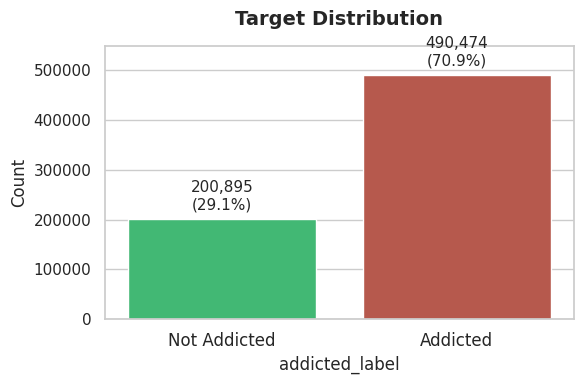

In [3]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    x='addicted_label',
    data=df,
    hue='addicted_label',
    palette=['#2ecc71', '#c74c3c'],
    legend=False
)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Not Addicted', 'Addicted'], fontsize=12)
plt.title('Target Distribution', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Count')

# Add headroom so labels don't overlap the title
ax.set_ylim(0, df['addicted_label'].value_counts().max() * 1.12)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}\n({p.get_height()/len(df)*100:.1f}%)',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

### 3.2 Feature Correlation with Target

Screen-time features dominate across the board. `sleep_hours`, `age`, and `notifications_per_day` carry virtually no linear signal. Categorical features `gender` and `stress_level` showed less than 2% variation in addiction rates across categories — essentially useless for prediction on their own, but kept in the model since dropping them hurt the score.

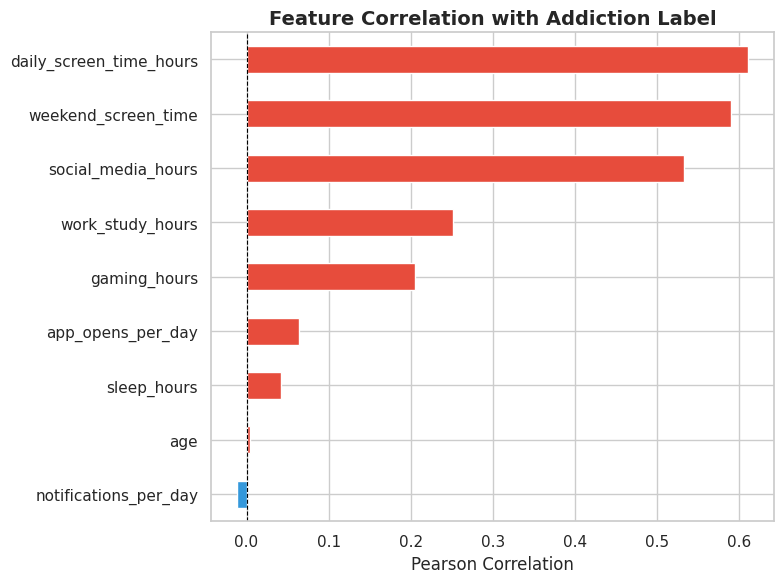

In [4]:
corr = df.corr(numeric_only=True)['addicted_label'].drop('addicted_label').sort_values()
plt.figure(figsize=(8, 6))
corr.plot(kind='barh', color=['#e74c3c' if x > 0 else '#3498db' for x in corr])
plt.title('Feature Correlation with Addiction Label', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

### 3.3 Screen Time Distribution by Addiction Status

Non-addicted users concentrate between 2–6 hours of daily screen time. Addicted users dominate above 7 hours with a peak around 9–10 hours. This crossover at **7 hours** directly inspired the threshold-based FE feature `high_screen_time`.

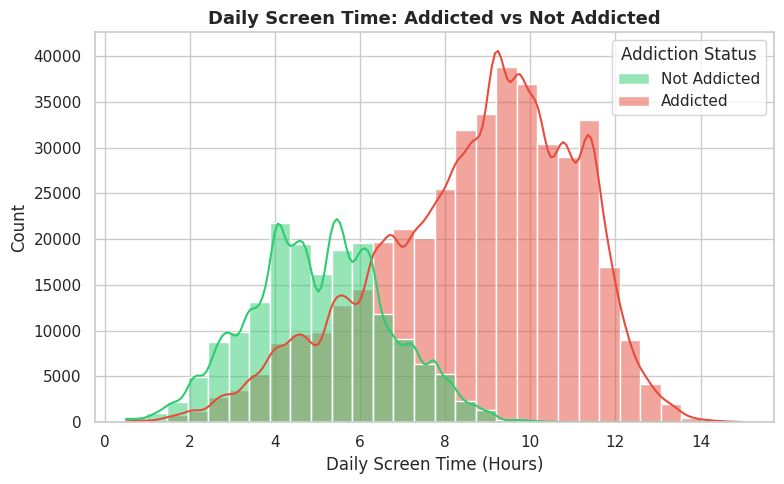

In [5]:
df_plot = df.copy()
df_plot['Addiction Status'] = df_plot['addicted_label'].map({0: 'Not Addicted', 1: 'Addicted'})

plt.figure(figsize=(8, 5))
sns.histplot(data=df_plot, x='daily_screen_time_hours',
             hue='Addiction Status', hue_order=['Not Addicted', 'Addicted'],
             bins=30, kde=True, palette=['#2ecc71', '#e74c3c'])
plt.title('Daily Screen Time: Addicted vs Not Addicted', fontsize=13, fontweight='bold')
plt.xlabel('Daily Screen Time (Hours)')
plt.tight_layout()
plt.show()

### 3.4 Top 3 Features — Boxplots

All three top features show clear median separation between addicted and non-addicted groups — daily screen time gap of ~4 hours, weekend screen time gap of ~3 hours, social media gap of ~1.5 hours. These three are the primary drivers of prediction.

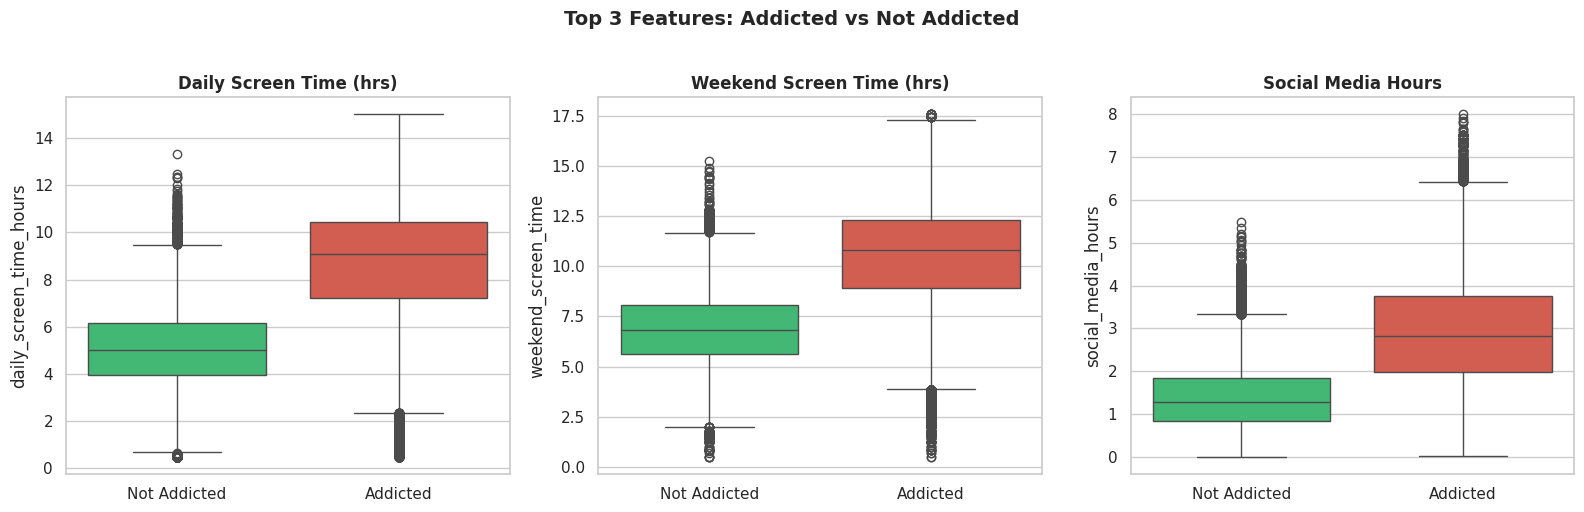

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
top_features = ['daily_screen_time_hours', 'weekend_screen_time', 'social_media_hours']
titles = ['Daily Screen Time (hrs)', 'Weekend Screen Time (hrs)', 'Social Media Hours']

for ax, feat, title in zip(axes, top_features, titles):
    sns.boxplot(x='addicted_label', y=feat, hue='addicted_label',
                data=df, palette=['#2ecc71', '#e74c3c'], legend=False, ax=ax)
    ax.set_xticklabels(['Not Addicted', 'Addicted'])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Top 3 Features: Addicted vs Not Addicted', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

Applied identically to train and test **before** any split or imputation so both stay in sync.

**13 features engineered across 4 types:**

- **Threshold flags** — binary signals at EDA crossover points (e.g. screen time > 7hrs is where addicted users dominate)
- **Ordinal bins** — capture gradients better than a single cutoff; `screen_time_bin` ended up as a top feature in the final model
- **Gap features** — difference between weekend and weekday behavior; addicted users tend to use phone even more on weekends when less structured activity
- **Ratio features** — how each activity relates to total screen time; captures proportional behavior rather than raw hours

Two features were tested and removed as they hurt the score (`notif_per_open` and `entertainment_ratio`) — kept as comments for reference.

In [7]:
def features(df):
    df = df.copy()

    # Binary mapping for Yes/No column
    df['academic_work_impact'] = df['academic_work_impact'].map({'No': 0, 'Yes': 1})

    # Threshold flags — crossover points from EDA
    df['high_screen_time']    = (df['daily_screen_time_hours'] > 7).astype(int)
    df['high_weekend_screen'] = (df['weekend_screen_time'] > 10).astype(int)
    df['high_social_media']   = (df['social_media_hours'] > 2).astype(int)

    # Gap features — weekend vs weekday behavior
    df['weekend_gap']     = df['weekend_screen_time'] - df['daily_screen_time_hours']
    df['leftover_screen'] = df['daily_screen_time_hours'] - df['social_media_hours'] - df['gaming_hours'] - df['work_study_hours']

    # Ratio features — proportional behavior relative to total screen time
    df['social_ratio']          = df['social_media_hours']   / (df['daily_screen_time_hours'] + 1)
    df['weekend_weekday_ratio'] = df['weekend_screen_time']  / (df['daily_screen_time_hours'] + 1)
    df['gaming_ratio']          = df['gaming_hours']         / (df['daily_screen_time_hours'] + 1)
    df['apps_open_per_hour']    = df['app_opens_per_day']    / (df['daily_screen_time_hours'] + 1)
    df['work_ratio']            = df['work_study_hours']     / (df['daily_screen_time_hours'] + 1)

    # Tested and removed — hurt the score
    # df['notif_per_open']      = df['notifications_per_day'] / (df['app_opens_per_day'] + 1)
    # df['entertainment_ratio'] = (df['social_media_hours'] + df['gaming_hours']) / (df['daily_screen_time_hours'] + 1)

    # Ordinal bins — gradient signal stronger than single threshold
    df['screen_time_bin'] = pd.cut(
        df['daily_screen_time_hours'],
        bins=[0, 4, 7, 10, 15], labels=[0, 1, 2, 3]
    ).astype(float)

    df['weekend_screen_bin'] = pd.cut(
        df['weekend_screen_time'],
        bins=[0, 5, 10, 13, 18], labels=[0, 1, 2, 3]
    ).astype(float)

    df['high_social_bin'] = pd.cut(
        df['social_media_hours'],
        bins=[0, 1, 2, 4, 8], labels=[0, 1, 2, 3]
    ).astype(float)

    return df

df   = features(df)
test = features(test)

print(f'Train after FE: {df.shape}, Test after FE: {test.shape}')

Train after FE: (691369, 26), Test after FE: (296302, 25)


## 5. Preprocessing Pipeline

Columns split into three groups for `ColumnTransformer`:
- **Numerical** — median imputation (robust to outliers and skewed distributions)
- **Ordinal** (`stress_level`) — mode imputation + ordered encoding (Low < Medium < High)
- **Nominal** (`gender`) — mode imputation + one-hot encoding

sklearn `Pipeline` inside `ColumnTransformer` ensures the imputer fits **only on training data** — no leakage from validation folds into imputation statistics. Stratified 80/20 split preserves the 70/30 class balance.

In [8]:
num_cols     = df.select_dtypes(include=['float64', 'int64']).columns.to_list()
num_cols.remove('addicted_label')
ordinal_cols = ['stress_level']
ohe_col      = ['gender']

X = df.drop('addicted_label', axis=1)
y = df['addicted_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Numerical cols ({len(num_cols)}): {num_cols}')
print(f'Ordinal cols: {ordinal_cols} | OHE cols: {ohe_col}')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

Numerical cols (23): ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'academic_work_impact', 'high_screen_time', 'high_weekend_screen', 'high_social_media', 'weekend_gap', 'leftover_screen', 'social_ratio', 'weekend_weekday_ratio', 'gaming_ratio', 'apps_open_per_hour', 'work_ratio', 'screen_time_bin', 'weekend_screen_bin', 'high_social_bin']
Ordinal cols: ['stress_level'] | OHE cols: ['gender']
X_train: (553095, 25), X_test: (138274, 25)


In [9]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[['Low', 'Medium', 'High']],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

ohe_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num',     num_pipeline,     num_cols),
    ('ordinal', ordinal_pipeline, ordinal_cols),
    ('ohe',     ohe_pipeline,     ohe_col)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)
X_proc       = preprocessor.fit_transform(X)
test_proc    = preprocessor.transform(test)

ohe_feature_names = preprocessor.named_transformers_['ohe']['encoder'].get_feature_names_out(ohe_col).tolist()
feature_names = num_cols + ordinal_cols + ohe_feature_names

print(f'Total features after preprocessing: {len(feature_names)}')

Total features after preprocessing: 27


## 6. Hyperparameter Tuning with Optuna

3-fold Stratified CV inside the objective for reliable, leakage-free score estimates. XGBoost run on GPU (`device='cuda'`, `tree_method='hist'`) for faster trial times — made running 200 trials feasible.

Key findings from tuning experiments:
- 100 trials: best found early, score 0.96511
- 200 trials: best found at trial 178, score 0.96514 — longer search was worth it
- After adding new FE features, 30 trials with updated feature set: score 0.96602

> **Note:** Optuna block commented out after tuning. Best parameters hardcoded in Section 7 for reproducibility.

In [10]:
# def objective(trial):
#     params = {
#         'n_estimators':     trial.suggest_int(  'n_estimators',     500,  2000),
#         'max_depth':        trial.suggest_int(  'max_depth',        3,    10),
#         'learning_rate':    trial.suggest_float('learning_rate',    0.01, 0.3,  log=True),
#         'subsample':        trial.suggest_float('subsample',        0.6,  1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6,  1.0),
#         'min_child_weight': trial.suggest_int(  'min_child_weight', 10,   80),
#         'reg_alpha':        trial.suggest_float('reg_alpha',        1e-8, 10.0, log=True),
#         'reg_lambda':       trial.suggest_float('reg_lambda',       1e-8, 10.0, log=True),
#         'random_state': 42,
#         'device': 'cuda',
#         'n_jobs': -1,
#         'eval_metric': 'auc',
#         'tree_method': 'hist',
#         'objective': 'binary:logistic'
#     }
#     cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
#     model = XGBClassifier(**params)
#     scores = cross_val_score(model, X_train_proc, y_train, cv=cv, scoring='roc_auc')
#     return scores.mean()

# study = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=42),
#     pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
# )
# study.optimize(objective, n_trials=30, show_progress_bar=True)
# print(f'Best AUC: {study.best_value:.5f}')
# print(f'Best params: {study.best_params}')

## 7. Train Final XGBoost with Best Parameters

Retrained on the **full training set** using best params from Optuna after adding all 13 FE features.

**Public leaderboard score: 0.96602**

In [11]:
best_params_200_trials = {
    'n_estimators':     1653,
    'max_depth':        5,
    'learning_rate':    0.11295051693799686,
    'subsample':        0.9726811384988081,
    'colsample_bytree': 0.6945536095069618,
    'min_child_weight': 30,
    'reg_alpha':        9.868917138642198e-08,
    'reg_lambda':       2.724606720807439,
    'random_state':     42,
    'device':           'cuda',
    'n_jobs':           -1,
    'eval_metric':      'auc',
    'tree_method':      'hist',
    'objective':        'binary:logistic'
}


# best_params = {
#     'n_estimators':     1749,
#     'max_depth':        4,
#     'learning_rate':    0.13249280729286372,
#     'subsample':        0.9955040072897259,
#     'colsample_bytree': 0.6161209206014088,
#     'min_child_weight': 26,
#     'reg_alpha':        1.0235465354628705e-08,
#     'reg_lambda':       0.00017751764458547785,
#     'random_state':     42,
#     'device':           'cuda',
#     'n_jobs':           -1,
#     'eval_metric':      'auc',
#     'tree_method':      'hist',
#     'objective':        'binary:logistic'
# }

model = XGBClassifier(**best_params_200_trials)
model.fit(X_proc, y)

val_model = XGBClassifier(**best_params_200_trials)
val_model.fit(X_train_proc, y_train)
val_preds = val_model.predict_proba(X_test_proc)[:, 1]
print(f'Validation AUC: {roc_auc_score(y_test, val_preds):.5f}')

Validation AUC: 0.96407


## 8. Feature Importance

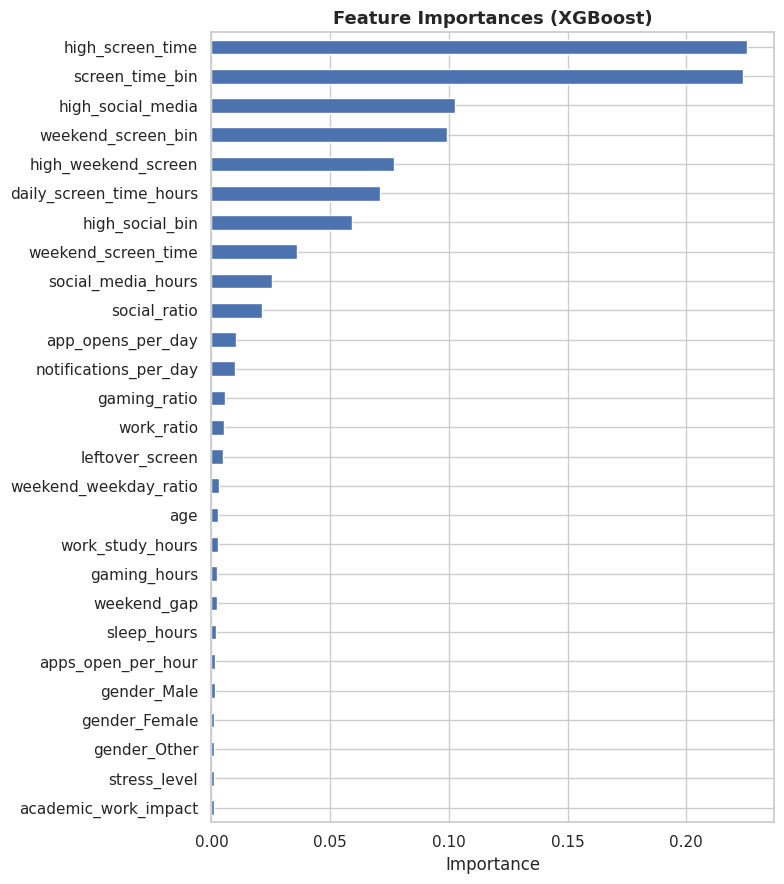

high_screen_time           0.225634
screen_time_bin            0.223751
high_social_media          0.102698
weekend_screen_bin         0.099023
high_weekend_screen        0.077075
daily_screen_time_hours    0.070785
high_social_bin            0.059281
weekend_screen_time        0.036213
social_media_hours         0.025352
social_ratio               0.021122
app_opens_per_day          0.010466
notifications_per_day      0.009802
gaming_ratio               0.005608
work_ratio                 0.005373
leftover_screen            0.004960
weekend_weekday_ratio      0.003065
age                        0.002902
work_study_hours           0.002805
gaming_hours               0.002496
weekend_gap                0.002191
sleep_hours                0.002065
apps_open_per_hour         0.001611
gender_Male                0.001353
gender_Female              0.001202
gender_Other               0.001101
stress_level               0.001085
academic_work_impact       0.000979
dtype: float32


In [12]:
importances = pd.Series(
    model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
importances.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Feature Importances (XGBoost)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print(importances)

## 9. Predict and Submit

In [13]:
test_preds = model.predict_proba(test_proc)[:, 1]

submission = pd.DataFrame({
    'id':             test_ids,
    'addicted_label': test_preds
})

submission.to_csv('submission.csv', index=False)
print(f'submission.csv saved — {len(submission)} rows')
submission.head()

submission.csv saved — 296302 rows


,id,addicted_label
0,691369,0.999652
1,691370,0.937293
2,691371,0.955102
3,691372,0.988573
4,691373,0.999033


## 10. Key Takeaways

**Score progression:**
- Baseline LightGBM: 0.96138
- LightGBM + Optuna: 0.96488
- XGBoost + Optuna (100 trials): 0.96511
- XGBoost + Optuna (200 trials): 0.96514
- + `weekend_gap` and `leftover_screen`: 0.96578
- + ratio features (`social_ratio`, `gaming_ratio`, `work_ratio`, etc.): **0.96602**

**What worked:**
- **Screen time features dominate** — `daily_screen_time_hours`, `weekend_screen_time`, `social_media_hours` are the three strongest raw signals confirmed by both EDA and feature importance
- **FE moved the score more than tuning** — going from 0.96514 to 0.96602 through feature engineering was more impactful than running extra Optuna trials
- **Gap features captured behavioral patterns** — `weekend_gap` and `leftover_screen` captured addiction patterns that raw columns couldn't explain individually
- **Ratio features added meaningful signal** — `work_ratio` was the strongest ratio feature, capturing how little of screen time is productive vs total
- **XGBoost on GPU beat LightGBM** (0.96514 vs 0.96488) — `hist` tree method on CUDA found a better parameter region
- **Do NOT drop weak features** — removing `sleep_hours`, `age`, `gender`, `stress_level` based on low feature importance dropped the score from 0.965 to 0.894. Even low-importance features contribute small signals that add up
- **Feature importance doesn't tell the whole story** — `weekend_gap` and `leftover_screen` weren't in the top 7 by importance yet pushed the score from 0.96514 to 0.96578. The real test is always the leaderboard score
- **200 Optuna trials showed diminishing returns** — best params found at trial 178, only +0.00003 over 100 trials. 25-30 trials is enough for most cases

Feedback and suggestions welcome — upvote if this helped! 🙌